<a href="https://colab.research.google.com/github/Purvarty/DATA-SCIENCE-/blob/main/DATA_SCIENCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔍 Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ID                       100000 non-null  int64  
 1   Age                      100000 non-null  int64  
 2   Gender                   100000 non-null  object 
 3   Region                   100000 non-null  object 
 4   Family_Income            100000 non-null  int64  
 5   Family_History_Diabetes  100000 non-null  object 
 6   Parent_Diabetes_Type     34903 non-null   object 
 7   Genetic_Risk_Score       100000 non-null  int64  
 8   BMI                      100000 non-null  float64
 9   Physical_Activity_Level  100000 non-null  object 
 10  Dietary_Habits           100000 non-null  object 
 11  Fast_Food_Intake         100000 non-null  int64  
 12  Smoking                  100000 non-null  object 
 13  Alcohol_Consumption      100000 non-

/tmp/ipython-input-2490083082.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip().title() if isinstance(x, str) else x)



✅ Cleaned and preprocessed data saved as 'cleaned_diabetes_data.csv'


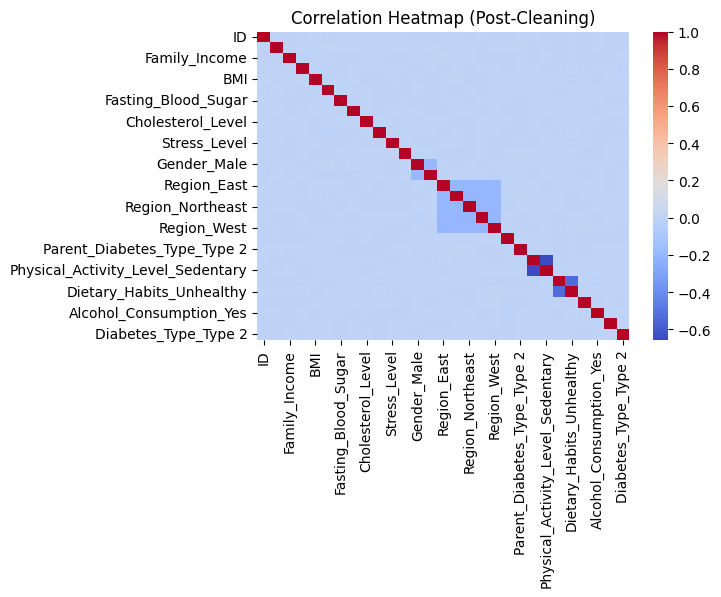


🔹 Descriptive Statistics:
                  ID           Age  Family_Income  Genetic_Risk_Score  \
count  1.000000e+05  1.000000e+05   1.000000e+05        1.000000e+05   
mean  -3.637979e-17  9.258372e-17   1.259437e-16       -1.164580e-16   
std    1.000005e+00  1.000005e+00   1.000005e+00        1.000005e+00   
min   -1.732033e+00 -1.587328e+00  -1.733448e+00       -1.568601e+00   
25%   -8.660167e-01 -9.533972e-01  -8.631390e-01       -8.722711e-01   
50%    0.000000e+00 -2.500857e-03   7.935114e-04        1.722232e-01   
75%    8.660167e-01  9.483955e-01   8.663729e-01        8.685527e-01   
max    1.732033e+00  1.582326e+00   1.735033e+00        1.564882e+00   

                BMI  Fast_Food_Intake  Fasting_Blood_Sugar         HbA1c  \
count  1.000000e+05      1.000000e+05         1.000000e+05  1.000000e+05   
mean  -7.103651e-16      6.366463e-17         7.915446e-17  5.984369e-16   
std    1.000005e+00      1.000005e+00         1.000005e+00  1.000005e+00   
min   -1.737118e+00

In [ ]:
# --- DATA CLEANING & PREPROCESSING PIPELINE ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv("diabetes_young_adults_india.csv")

print("🔍 Initial Dataset Info:")
print(df.info())
print("\nShape:", df.shape)

# 2️⃣ Basic inspection
print("\n🔹 Missing Values per Column:")
print(df.isnull().sum())

print("\n🔹 Duplicate Rows:", df.duplicated().sum())

# 3️⃣ Remove duplicates
df = df.drop_duplicates()

# 4️⃣ Handle missing values
# Strategy: Fill numeric columns with median, categorical with mode
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# 5️⃣ Fix inconsistent data / categorical standardization
# Example: unify labels like "Type1", "type 1", "TYPE 1" → "Type 1"
df = df.applymap(lambda x: x.strip().title() if isinstance(x, str) else x)

# 6️⃣ Convert categorical variables to numeric (One-Hot Encoding)
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 7️⃣ Outlier Detection & Treatment (IQR method)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

# 8️⃣ Feature Scaling (Normalization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 9️⃣ Save cleaned dataset
df.to_csv("cleaned_diabetes_data.csv", index=False)
print("\n✅ Cleaned and preprocessed data saved as 'cleaned_diabetes_data.csv'")

# 🔟 Quick summary visualization
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (Post-Cleaning)")
plt.show()

# 🧾 Basic descriptive statistics
summary = df.describe()
print("\n🔹 Descriptive Statistics:\n", summary)


Dataset Shape: (100000, 22)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ID                       100000 non-null  int64  
 1   Age                      100000 non-null  int64  
 2   Gender                   100000 non-null  object 
 3   Region                   100000 non-null  object 
 4   Family_Income            100000 non-null  int64  
 5   Family_History_Diabetes  100000 non-null  object 
 6   Parent_Diabetes_Type     34903 non-null   object 
 7   Genetic_Risk_Score       100000 non-null  int64  
 8   BMI                      100000 non-null  float64
 9   Physical_Activity_Level  100000 non-null  object 
 10  Dietary_Habits           100000 non-null  object 
 11  Fast_Food_Intake         100000 non-null  int64  
 12  Smoking                  100000 non-null  object 
 13  Alcohol_Consumpti

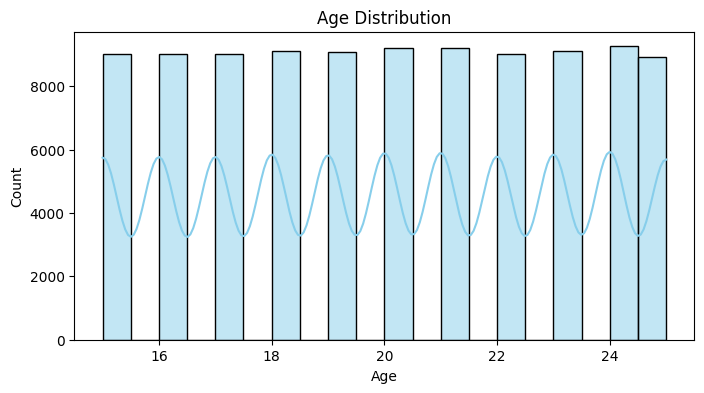

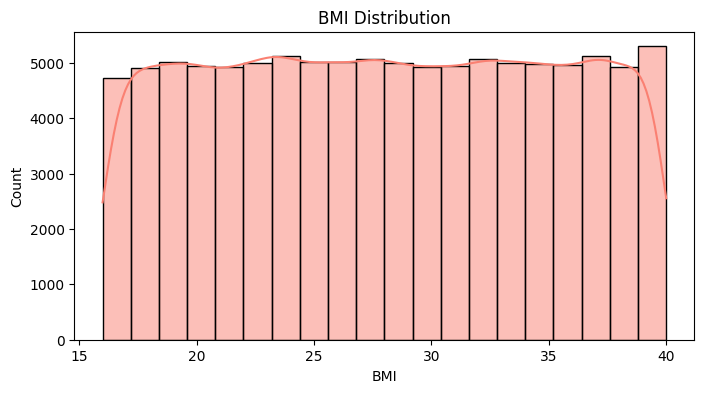

/tmp/ipython-input-2211962577.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='pastel')


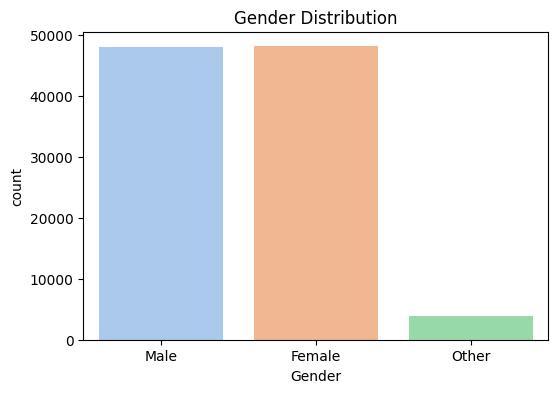

/tmp/ipython-input-2211962577.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_Type', data=df, palette='muted')


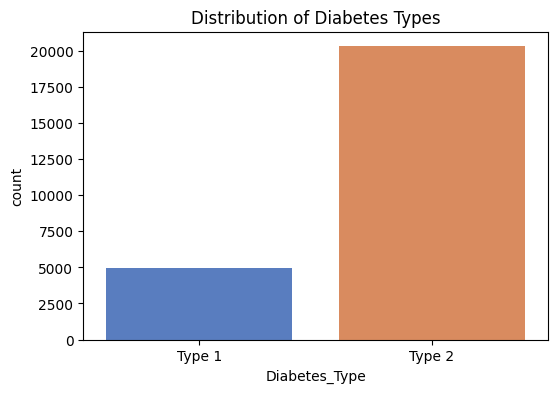

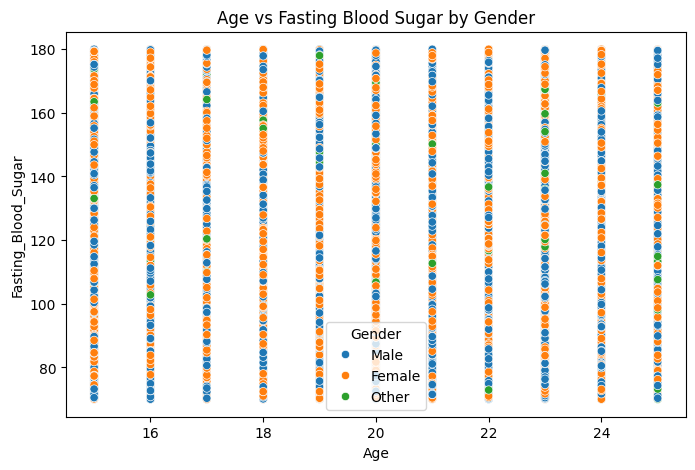

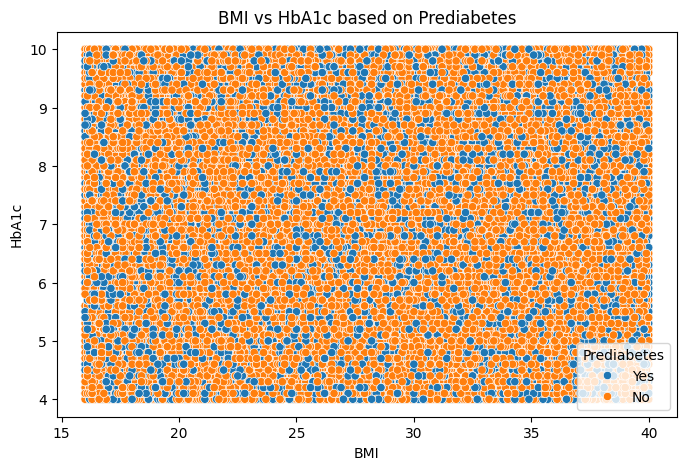

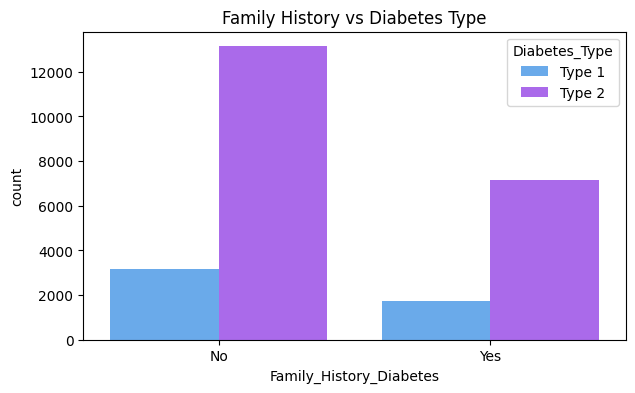

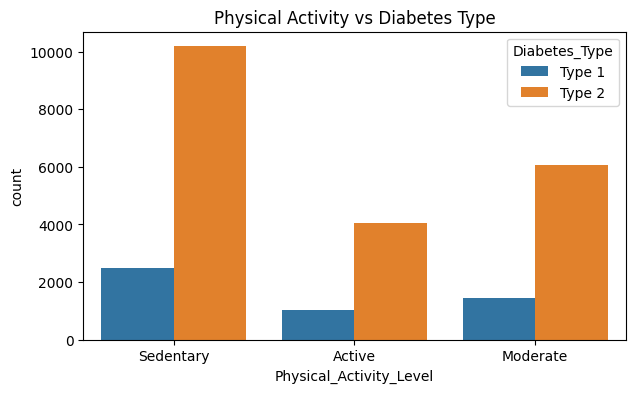

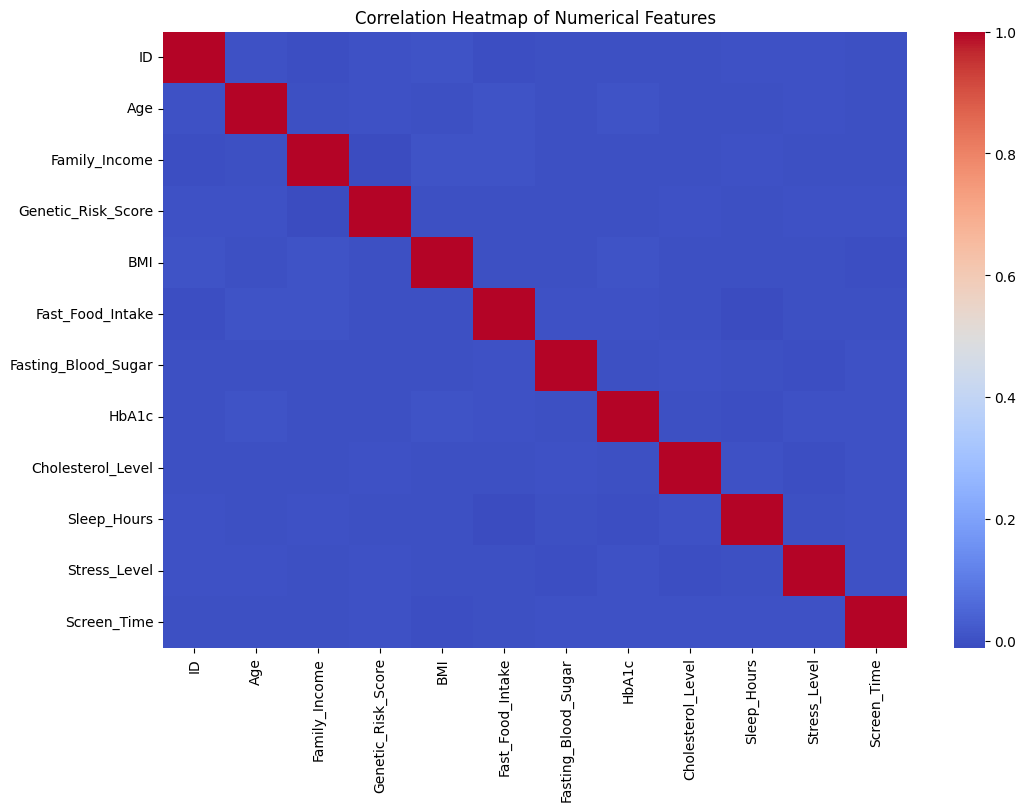

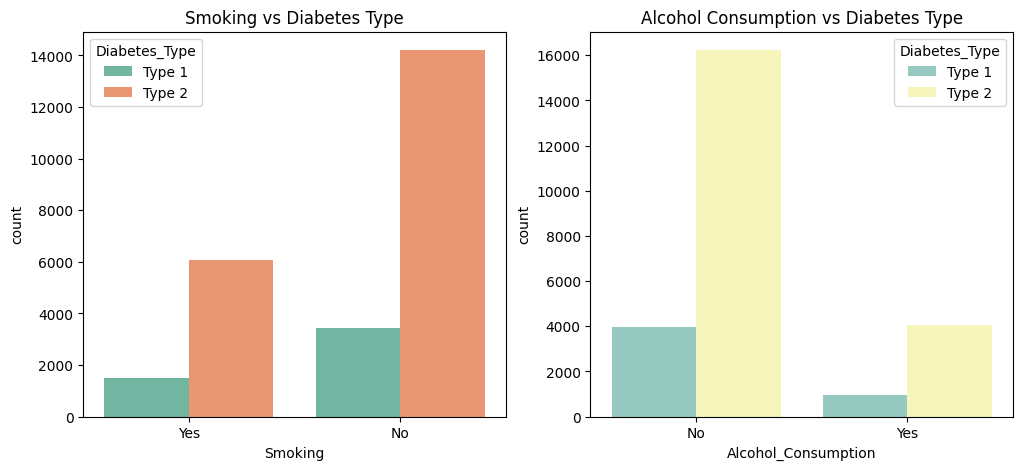

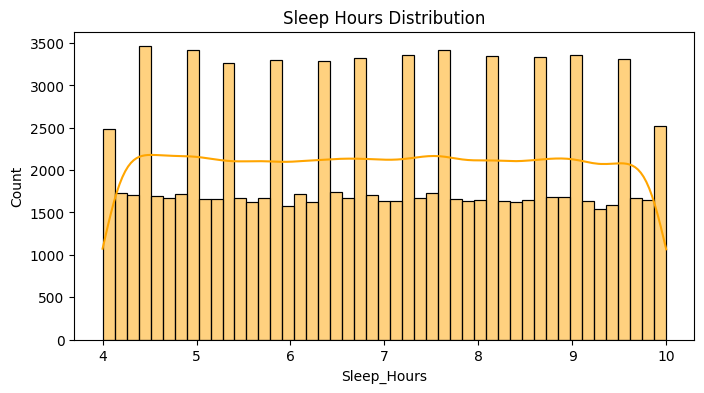

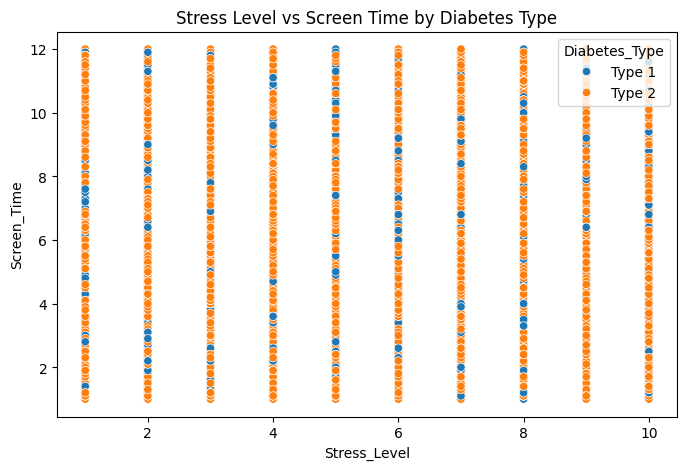


Top 5 correlations with HbA1c:
HbA1c           1.000000
Age             0.006189
BMI             0.005600
Stress_Level    0.002687
Screen_Time     0.002138
Name: HbA1c, dtype: float64

Top 5 correlations with Fasting_Blood_Sugar:
Fasting_Blood_Sugar    1.000000
Fast_Food_Intake       0.002697
Screen_Time            0.002519
Cholesterol_Level      0.001145
ID                     0.000203
Name: Fasting_Blood_Sugar, dtype: float64


In [ ]:
# --- EXPLORATORY DATA ANALYSIS (EDA) ---

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
df = pd.read_csv("diabetes_young_adults_india.csv")

# 2️⃣ Basic overview
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe(include='all'))

# 3️⃣ Check for missing and duplicate values
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# 4️⃣ Univariate Analysis
# --- Age Distribution ---
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.show()

# --- BMI Distribution ---
plt.figure(figsize=(8,4))
sns.histplot(df['BMI'], bins=20, kde=True, color='salmon')
plt.title("BMI Distribution")
plt.show()

# --- Gender Count ---
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title("Gender Distribution")
plt.show()

# --- Diabetes Type Count ---
plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes_Type', data=df, palette='muted')
plt.title("Distribution of Diabetes Types")
plt.show()

# 5️⃣ Bivariate Analysis
# --- Age vs Fasting Blood Sugar ---
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fasting_Blood_Sugar', hue='Gender', data=df)
plt.title("Age vs Fasting Blood Sugar by Gender")
plt.show()

# --- BMI vs HbA1c (Blood Sugar Control Indicator) ---
plt.figure(figsize=(8,5))
sns.scatterplot(x='BMI', y='HbA1c', hue='Prediabetes', data=df)
plt.title("BMI vs HbA1c based on Prediabetes")
plt.show()

# --- Family History vs Diabetes Type ---
plt.figure(figsize=(7,4))
sns.countplot(x='Family_History_Diabetes', hue='Diabetes_Type', data=df, palette='cool')
plt.title("Family History vs Diabetes Type")
plt.show()

# --- Physical Activity vs Diabetes Type ---
plt.figure(figsize=(7,4))
sns.countplot(x='Physical_Activity_Level', hue='Diabetes_Type', data=df)
plt.title("Physical Activity vs Diabetes Type")
plt.show()

# 6️⃣ Correlation Analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# 7️⃣ Insights on Lifestyle Factors
# --- Smoking and Alcohol vs Diabetes Type ---
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='Smoking', hue='Diabetes_Type', data=df, ax=ax[0], palette='Set2')
ax[0].set_title("Smoking vs Diabetes Type")

sns.countplot(x='Alcohol_Consumption', hue='Diabetes_Type', data=df, ax=ax[1], palette='Set3')
ax[1].set_title("Alcohol Consumption vs Diabetes Type")
plt.show()

# --- Sleep Hours Distribution ---
plt.figure(figsize=(8,4))
sns.histplot(df['Sleep_Hours'], kde=True, color='orange')
plt.title("Sleep Hours Distribution")
plt.show()

# --- Stress vs Screen Time ---
plt.figure(figsize=(8,5))
sns.scatterplot(x='Stress_Level', y='Screen_Time', hue='Diabetes_Type', data=df)
plt.title("Stress Level vs Screen Time by Diabetes Type")
plt.show()

# 8️⃣ Key Correlations
print("\nTop 5 correlations with HbA1c:")
print(df.corr(numeric_only=True)['HbA1c'].sort_values(ascending=False).head(5))

print("\nTop 5 correlations with Fasting_Blood_Sugar:")
print(df.corr(numeric_only=True)['Fasting_Blood_Sugar'].sort_values(ascending=False).head(5))


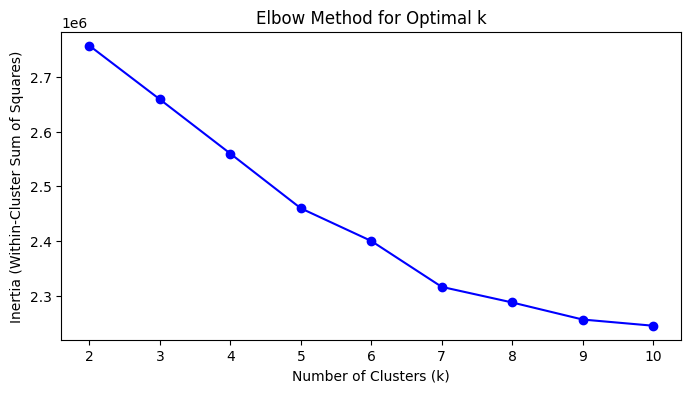

Silhouette Score for k=3: 0.063


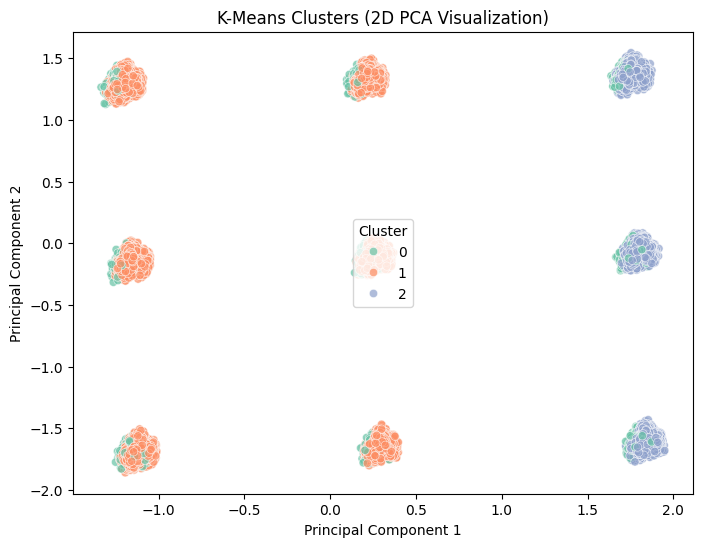


🔹 Cluster Summary (Mean Values):
               ID       Age  Family_Income  Genetic_Risk_Score       BMI  \
Cluster                                                                    
0       -0.030044  0.041249       0.007158            0.022696 -0.009924   
1        0.002496 -0.000480       0.001368           -0.003370  0.000954   
2       -0.001701 -0.004563      -0.004191            0.004761 -0.000867   

         Fast_Food_Intake  Fasting_Blood_Sugar     HbA1c  Cholesterol_Level  \
Cluster                                                                       
0               -0.015105            -0.022997 -0.014484           0.018438   
1                0.000837             0.001298 -0.001470          -0.001811   
2                0.000123             0.000131  0.005440           0.001698   

         Sleep_Hours  ...  Family_History_Diabetes_Yes  \
Cluster               ...                                
0           0.004952  ...                     0.349987   
1           0.0

In [ ]:
# --- CLUSTERING ANALYSIS PIPELINE ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1️⃣ Load cleaned/preprocessed dataset
df = pd.read_csv("cleaned_diabetes_data.csv")   # ensure this is numeric & scaled

# 2️⃣ Drop target variable (if any)
if 'Diabetes_Type' in df.columns:
    df_features = df.drop(columns=['Diabetes_Type'])
else:
    df_features = df.copy()

# 3️⃣ Feature Scaling (if not already scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# 4️⃣ Determine optimal number of clusters (Elbow Method)
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.show()

# 5️⃣ Choose k based on the elbow (e.g., k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 6️⃣ Evaluate clustering quality
sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score for k={optimal_k}: {sil_score:.3f}")

# 7️⃣ Visualize Clusters using PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='Set2', alpha=0.7)
plt.title("K-Means Clusters (2D PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# 8️⃣ Analyze cluster characteristics
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print("\n🔹 Cluster Summary (Mean Values):")
print(cluster_summary)

# 9️⃣ Optional: Save clustered dataset
df.to_csv("clustered_diabetes_data.csv", index=False)
print("\n✅ Clustering completed successfully!")
print("Clustered dataset saved as 'clustered_diabetes_data.csv'")


Columns in the loaded DataFrame: ['Age', 'Family_Income', 'Genetic_Risk_Score', 'BMI', 'Fast_Food_Intake', 'Fasting_Blood_Sugar', 'HbA1c', 'Cholesterol_Level', 'Diabetes_Type', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Gender_Male', 'Gender_Other', 'Region_East', 'Region_North', 'Region_Northeast', 'Region_South', 'Region_West', 'Family_History_Diabetes_Yes', 'Parent_Diabetes_Type_Type 2', 'Physical_Activity_Level_Moderate', 'Physical_Activity_Level_Sedentary', 'Dietary_Habits_Moderate', 'Dietary_Habits_Unhealthy', 'Smoking_Yes', 'Alcohol_Consumption_Yes', 'Prediabetes_Yes']
✅ Model Accuracy: 95.08%

🔹 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       985
           1       0.95      1.00      0.97     19015

    accuracy                           0.95     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.90      0.95      0.93     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


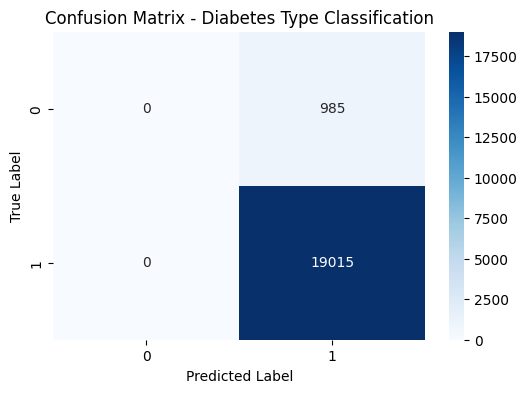

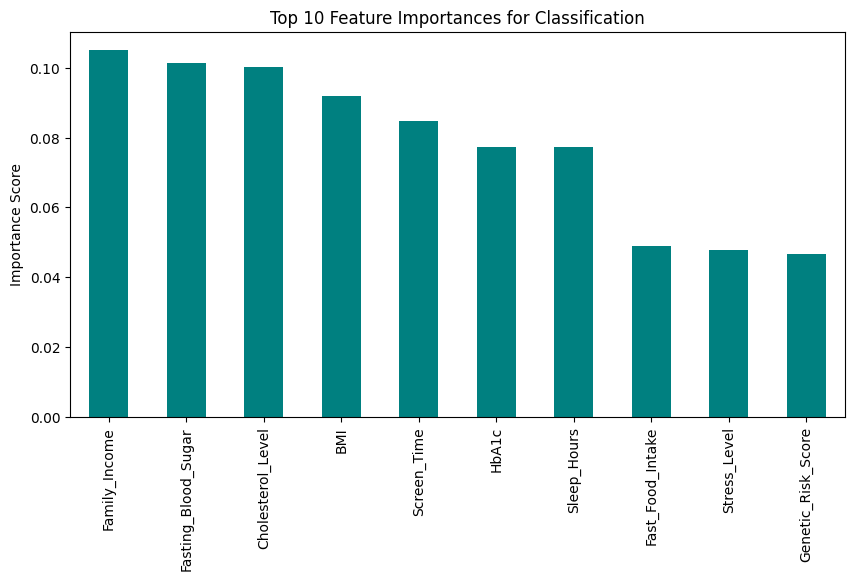


🧾 Results saved as 'diabetes_classification_results.csv'


In [ ]:
# --- DIABETES CLASSIFICATION PIPELINE ---

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Load dataset (already cleaned & preprocessed)
df = pd.read_csv("cleaned_diabetes_data.csv")

# Add this line to print columns for diagnosis
print("Columns in the loaded DataFrame:", df.columns.tolist())


# 2️⃣ Define target and features
target = 'Diabetes_Type'
X = df.drop(columns=[target])
y = df[target]

# 3️⃣ Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4️⃣ Feature scaling (if not already scaled)
# Note: 'Diabetes_Type' should not be scaled as it's the target variable.
# Ensure scaling was handled correctly in the preprocessing step.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5️⃣ Train Classification Model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6️⃣ Predictions
y_pred = model.predict(X_test)

# 7️⃣ Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy*100:.2f}%\n")

print("🔹 Classification Report:\n")
print(classification_report(y_test, y_pred))

# 8️⃣ Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Diabetes Type Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 9️⃣ Feature Importance
importances = pd.Series(model.feature_importances_, index=df.drop(columns=[target]).columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Feature Importances for Classification")
plt.ylabel("Importance Score")
plt.show()

# 10️⃣ Save the model results
results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
results.to_csv("diabetes_classification_results.csv", index=False)
print("\n🧾 Results saved as 'diabetes_classification_results.csv'")

In [ ]:
# --- DATA CLEANING AND PREPROCESSING PIPELINE ---

# Import required libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1️⃣ Load the dataset
df = pd.read_csv("diabetes_young_adults_india.csv")

# 2️⃣ Check for duplicates and remove them
df = df.drop_duplicates()

# 3️⃣ Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# (Optional) If any missing values exist, handle them
# Strategy: Fill numeric columns with median, categorical with mode
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        # Handle potential errors with mode()[0] on empty series
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            # Handle columns with all NaN or other issues if necessary
            print(f"Warning: Could not fill missing values for column '{col}' using mode.")


# 4️⃣ Drop irrelevant or unique identifier columns
df.drop(columns=['ID'], inplace=True)

# 5️⃣ Handle the target variable ('Diabetes_Type') separately
target_column = 'Diabetes_Type'
if target_column in df.columns:
    # Fill missing values in the target column if any
    if not df[target_column].mode().empty:
        df[target_column] = df[target_column].fillna(df[target_column].mode()[0])
    else:
         print(f"Warning: Could not fill missing values for target column '{target_column}' using mode.")

    # Label encode the target variable
    le_target = LabelEncoder()
    df[target_column] = le_target.fit_transform(df[target_column])
    print(f"\n'{target_column}' column label encoded.")
else:
    print(f"\nWarning: Target column '{target_column}' not found in the dataset.")


# 6️⃣ Encode other categorical columns (excluding the target)
categorical_cols = df.select_dtypes(include='object').columns
# Ensure the target column is not in the list of columns to be one-hot encoded
categorical_cols = [col for col in categorical_cols if col != target_column]


df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"One-hot encoded columns: {categorical_cols}")

# 7️⃣ Separate features (X) and target (y) AFTER encoding
X = df.drop(columns=[target_column])
y = df[target_column]


# 8️⃣ Scale numerical features only
scaler = StandardScaler()
# Select only numerical columns from the features DataFrame X
numeric_cols_X = X.select_dtypes(include=['int64', 'float64']).columns

# Apply scaling only to the numerical columns in X
X[numeric_cols_X] = scaler.fit_transform(X[numeric_cols_X])
print(f"Scaled numerical columns in features: {numeric_cols_X.tolist()}")


# 9️⃣ Display summary after preprocessing
print("\n✅ Data after cleaning and preprocessing:\n")
print(X.info())
print(y.head())

# 🔟 (Optional) Save cleaned data (features and target separately or combined)
# Saving features and target separately might be clearer for model training
X.to_csv("cleaned_features.csv", index=False)
y.to_csv("cleaned_target.csv", index=False)
print("\nFiles 'cleaned_features.csv' and 'cleaned_target.csv' saved successfully!")

Missing values before cleaning:
ID                             0
Age                            0
Gender                         0
Region                         0
Family_Income                  0
Family_History_Diabetes        0
Parent_Diabetes_Type       65097
Genetic_Risk_Score             0
BMI                            0
Physical_Activity_Level        0
Dietary_Habits                 0
Fast_Food_Intake               0
Smoking                        0
Alcohol_Consumption            0
Fasting_Blood_Sugar            0
HbA1c                          0
Cholesterol_Level              0
Prediabetes                    0
Diabetes_Type              74776
Sleep_Hours                    0
Stress_Level                   0
Screen_Time                    0
dtype: int64

'Diabetes_Type' column label encoded.
One-hot encoded columns: ['Gender', 'Region', 'Family_History_Diabetes', 'Parent_Diabetes_Type', 'Physical_Activity_Level', 'Dietary_Habits', 'Smoking', 'Alcohol_Consumption', 'Prediabetes']


📊 Linear Regression Performance:
MAE: 0.867
MSE: 1.002
RMSE: 1.001
R² Score: -0.000

📊 Random Forest Performance:
MAE: 0.872
MSE: 1.019
RMSE: 1.009
R² Score: -0.017

📊 KNN Regressor Performance:
MAE: 0.926
MSE: 1.205
RMSE: 1.098
R² Score: -0.203

🔍 Model Comparison:

               Model       MAE       MSE      RMSE  R² Score
0  Linear Regression  0.867417  1.002177  1.001088 -0.000285
1      Random Forest  0.872218  1.018845  1.009379 -0.016922
2      KNN Regressor  0.926178  1.204924  1.097690 -0.202649


/tmp/ipython-input-1556940597.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R² Score', palette='coolwarm')


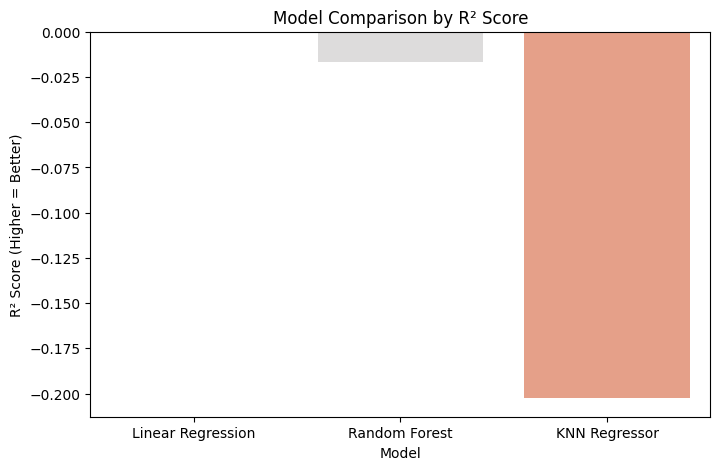

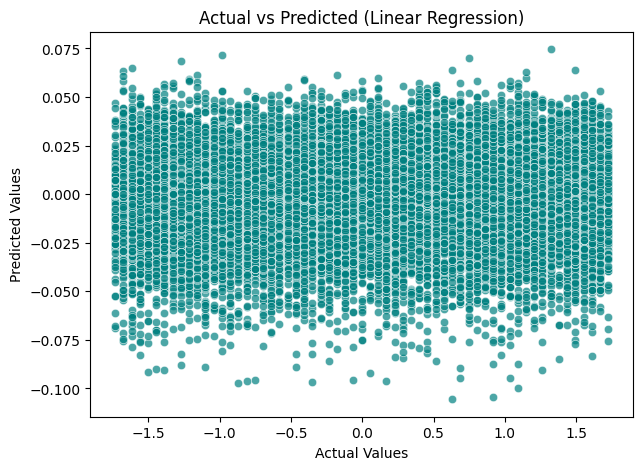


🏆 Best Performing Model: Linear Regression


In [ ]:
# --- MULTI-MODEL REGRESSION COMPARISON ---

# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1️⃣ Load dataset
df = pd.read_csv("cleaned_diabetes_data.csv")

# 2️⃣ Choose target column (numeric)
target = 'HbA1c'   # You can change this to another numeric variable if preferred
X = df.drop(columns=[target])
y = df[target]

# 3️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4️⃣ Feature Scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5️⃣ Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# 6️⃣ Train, Predict, and Evaluate
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })

    print(f"\n📊 {name} Performance:")
    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R² Score: {r2:.3f}")

# 7️⃣ Compare Models
results_df = pd.DataFrame(results)
print("\n🔍 Model Comparison:\n")
print(results_df.sort_values(by='R² Score', ascending=False))

# 8️⃣ Visualization: R² Comparison
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Model', y='R² Score', palette='coolwarm')
plt.title("Model Comparison by R² Score")
plt.ylabel("R² Score (Higher = Better)")
plt.show()

# 9️⃣ Actual vs Predicted for Best Model
best_model_name = results_df.loc[results_df['R² Score'].idxmax(), 'Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred_best, color='teal', alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

print(f"\n🏆 Best Performing Model: {best_model_name}")


X_train info before scaling:
<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                80000 non-null  float64
 1   Family_Income                      80000 non-null  float64
 2   Genetic_Risk_Score                 80000 non-null  float64
 3   BMI                                80000 non-null  float64
 4   Fast_Food_Intake                   80000 non-null  float64
 5   Fasting_Blood_Sugar                80000 non-null  float64
 6   HbA1c                              80000 non-null  float64
 7   Cholesterol_Level                  80000 non-null  float64
 8   Sleep_Hours                        80000 non-null  float64
 9   Stress_Level                       80000 non-null  float64
 10  Screen_Time                        80000 non-null  float64
 11  Gender_Male               

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9396 - loss: 0.2337 - val_accuracy: 0.9505 - val_loss: 0.1993
Epoch 2/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9519 - loss: 0.1970 - val_accuracy: 0.9505 - val_loss: 0.1978
Epoch 3/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9511 - loss: 0.1969 - val_accuracy: 0.9505 - val_loss: 0.1986
Epoch 4/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9506 - loss: 0.1979 - val_accuracy: 0.9505 - val_loss: 0.1978
Epoch 5/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9512 - loss: 0.1955 - val_accuracy: 0.9505 - val_loss: 0.1975
Epoch 6/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9496 - loss: 0.2002 - val_accuracy: 0.9505 - val_loss: 0.1972
Epoch 7/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9528 - loss: 0.1900 - val_accuracy: 0.9505 - val_loss: 0.1978
Epoch 8/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9513 - loss: 0.1943 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


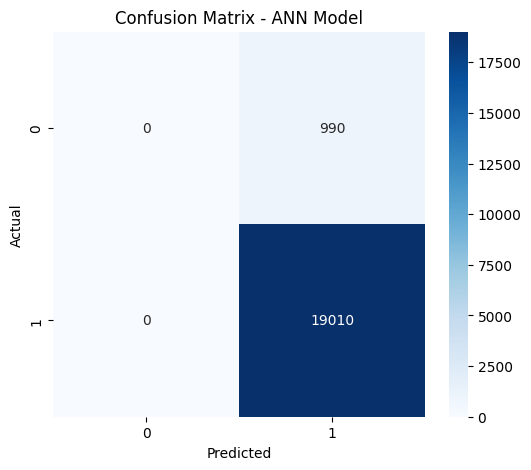

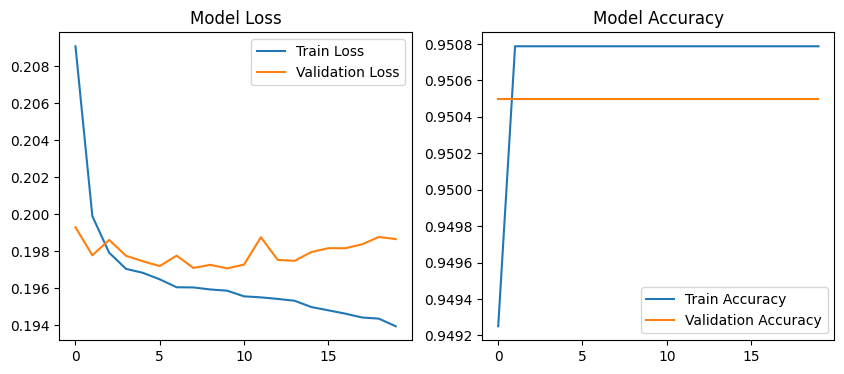

In [ ]:
# --- DEEP LEARNING MODEL (ANN) FOR DIABETES PREDICTION ---

# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Load the cleaned features and target
X = pd.read_csv("cleaned_features.csv")
y = pd.read_csv("cleaned_target.csv")

# Ensure target is a 1D array for LabelEncoder
y = y.values.ravel()

# 2️⃣ Encode categorical target variable (already done in cleaning, but good practice to confirm if loading separately)
# If y is already label encoded (as saved in cleaned_target.csv), this step might not be strictly necessary,
# but it's included here as a safeguard or if loading a raw target column.
# Assuming cleaned_target.csv is already label encoded:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)


# 3️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Standardize features
scaler = StandardScaler()

# Add this line to print the info of X_train before scaling
print("X_train info before scaling:")
X_train.info()


# Select only numerical columns from the features DataFrame X
numeric_cols_X = X_train.select_dtypes(include=['int64', 'float64']).columns

# Apply scaling only to the numerical columns in X
X_train[numeric_cols_X] = scaler.fit_transform(X_train[numeric_cols_X])
X_test[numeric_cols_X] = scaler.transform(X_test[numeric_cols_X])


# 5️⃣ Build the ANN model
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Use 'softmax' if more than 2 classes
])

# 6️⃣ Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',  # use 'sparse_categorical_crossentropy' if multiclass
              metrics=['accuracy'])

# 7️⃣ Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 8️⃣ Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32") # For binary classification

print("\n✅ Model Evaluation Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9️⃣ Confusion Matrix Visualization
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - ANN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔟 Plot training history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

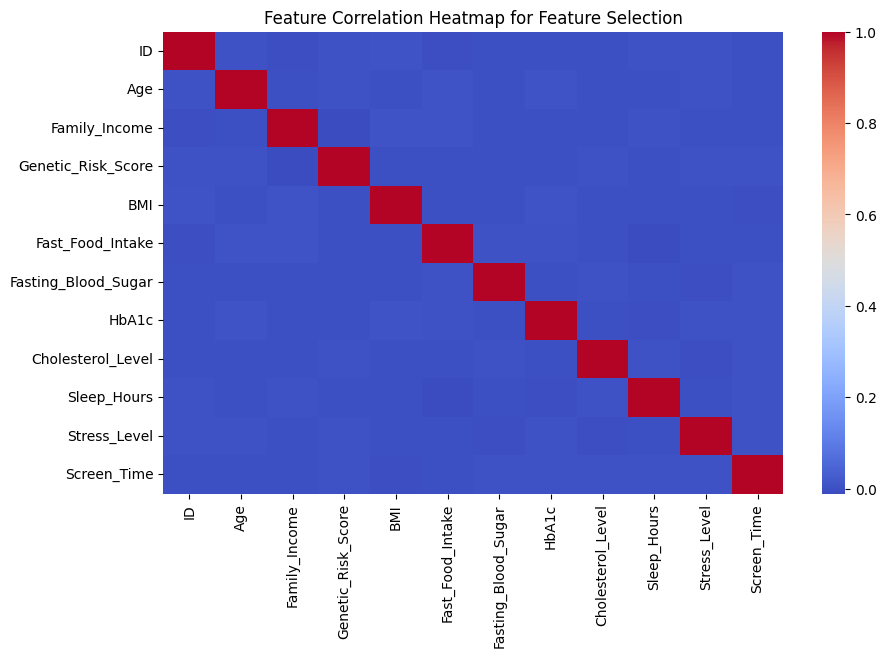

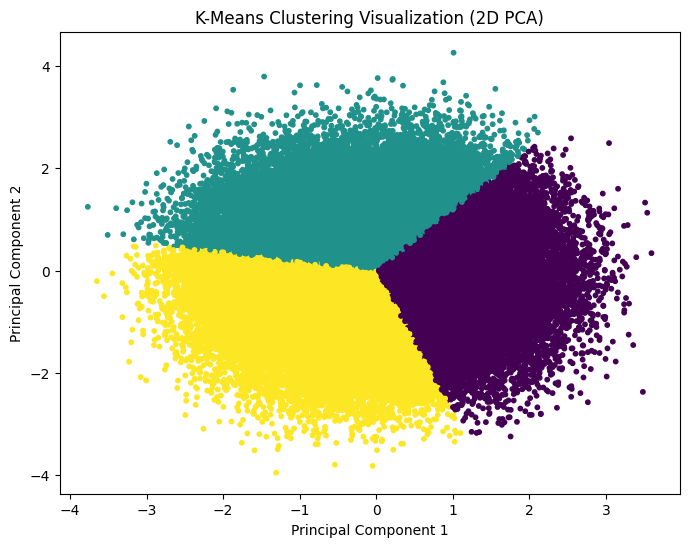

In [ ]:
# 📊 Simple Graphs for Clustering & Feature Selection

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("diabetes_young_adults_india.csv")

# Select numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"]).dropna()

# --- 1️⃣ Feature Correlation Heatmap (Feature Selection) ---
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap for Feature Selection")
plt.show()

# --- 2️⃣ Clustering Visualization (KMeans + PCA) ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# PCA to 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_data)

# Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap="viridis", s=10)
plt.title("K-Means Clustering Visualization (2D PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()
